# Week 3 Day 5 — Hyperparameter Tuning

## What I built:
- GridSearchCV on Decision Tree — tried all 30 combinations
- RandomizedSearchCV on Random Forest — tried 20 of 640 combinations
- Plotted cv_results — score vs rank, colored by fit time
- Compared top 5 combinations with fit time tradeoff

## Key concepts:

**GridSearchCV:**
- Tries ALL combinations in param_grid
- 30 combinations × 5 folds = 150 fits
- Best: criterion=entropy, max_depth=3 → accuracy=0.8249
- Use when param space is small (<100 combinations)

**RandomizedSearchCV:**
- Tries N random combinations only
- 20 combinations × 5 folds = 100 fits
- Best: n_estimators=300, max_depth=10 → accuracy=0.8418
- Use when param space is large (100+ combinations)

**n_jobs=-1:**
- Uses all CPU cores — parallelizes fits
- Always use for GridSearch and RandomizedSearch

**Fit time vs score tradeoff:**
- Rank 1: depth=10, trees=300 → 0.8418, 1.88s ← best balance
- Rank 2: depth=10, trees=500 → 0.8373, 3.40s ← slower, worse
- More trees ≠ always better — check fit time too

## Results — Titanic:
GridSearchCV best   : 0.8249 (Decision Tree)
RandomizedSearchCV  : 0.8418 (Random Forest) ← best so far

# GridSearchCV on Decision Tree:

In [1]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score

# load Titanic
df = pd.read_csv('train.csv')
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone']    = (df['FamilySize'] == 1).astype(int)
df['Title']      = df['Name'].apply(
                       lambda name: name.split(',')[1]
                                        .split('.')[0].strip())
df['Title']      = df['Title'].map({
                       'Mr': 0, 'Miss': 1, 'Mrs': 2,
                       'Master': 3}).fillna(4)

num_cols = ['Age', 'Fare', 'FamilySize', 'Title']
cat_cols = ['Sex', 'Embarked', 'Pclass']
X = df[num_cols + cat_cols]
y = df['Survived']

# preprocessor
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# pipeline with decision tree
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

# param grid
param_grid = {
    'model__max_depth'       : [3, 5, 7, 10, None],
    'model__min_samples_split': [2, 5, 10],
    'model__criterion'       : ['gini', 'entropy']
}

# GridSearchCV — tries ALL combinations
skfold = StratifiedKFold(n_splits=5)
grid_search = GridSearchCV(
    pipe, param_grid,
    cv=skfold,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X, y)

print("=" * 50)
print("   GRIDSEARCHCV RESULTS")
print("=" * 50)
print(f"  Best score  : {grid_search.best_score_:.4f}")
print(f"  Best params : {grid_search.best_params_}")
print(f"  Total fits  : {len(grid_search.cv_results_['mean_test_score'])}")
print("=" * 50)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
   GRIDSEARCHCV RESULTS
  Best score  : 0.8249
  Best params : {'model__criterion': 'entropy', 'model__max_depth': 3, 'model__min_samples_split': 2}
  Total fits  : 30


# RandomizedSearchCV on Random Forest:

In [2]:
from sklearn.ensemble import RandomForestClassifier

# larger param space — too many for GridSearch
param_dist = {
    'model__n_estimators'    : [100, 200, 300, 500],
    'model__max_depth'       : [3, 5, 7, 10, None],
    'model__max_features'    : ['sqrt', 'log2', 0.3, 0.5],
    'model__min_samples_leaf': [1, 2, 4, 6],
    'model__criterion'       : ['gini', 'entropy']
}

# total combinations = 4×5×4×4×2 = 640 — too many for GridSearch
# RandomizedSearch tries only 20

rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

random_search = RandomizedSearchCV(
    rf_pipe, param_dist,
    n_iter=20,
    cv=skfold,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
random_search.fit(X, y)

print("=" * 50)
print("   RANDOMIZEDSEARCHCV RESULTS")
print("=" * 50)
print(f"  Best score  : {random_search.best_score_:.4f}")
print(f"  Best params : {random_search.best_params_}")
print(f"  Total fits  : {len(random_search.cv_results_['mean_test_score'])}")
print("=" * 50)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
   RANDOMIZEDSEARCHCV RESULTS
  Best score  : 0.8418
  Best params : {'model__n_estimators': 300, 'model__min_samples_leaf': 4, 'model__max_features': 0.5, 'model__max_depth': 10, 'model__criterion': 'entropy'}
  Total fits  : 20


# Plot cv_results to understand tuning:

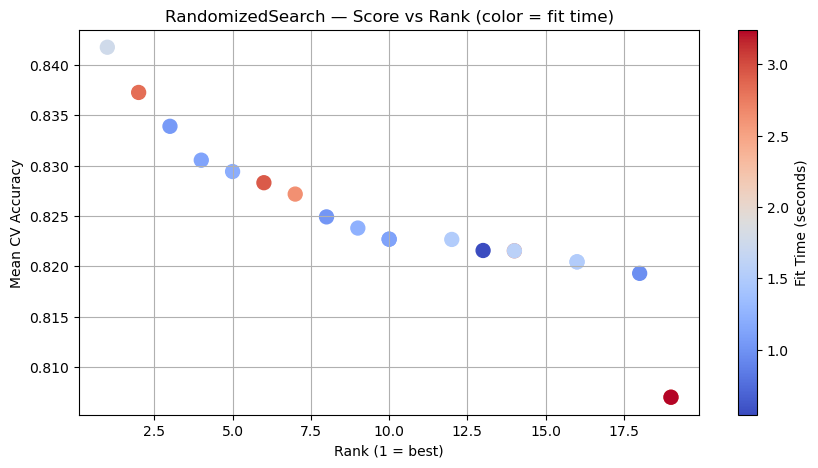

Top 5 combinations:
 rank_test_score  mean_test_score  mean_fit_time param_model__max_depth  param_model__n_estimators
               1         0.841761       1.766097                     10                        300
               2         0.837267       2.827656                     10                        500
               3         0.833902       1.058641                   None                        200
               4         0.830538       1.126677                   None                        200
               5         0.829408       1.203789                   None                        200


In [3]:
import matplotlib.pyplot as plt

# extract results
results = pd.DataFrame(random_search.cv_results_)

# plot mean test score vs rank
plt.figure(figsize=(10, 5))
plt.scatter(
    results['rank_test_score'],
    results['mean_test_score'],
    c=results['mean_fit_time'],
    cmap='coolwarm',
    s=100
)
plt.colorbar(label='Fit Time (seconds)')
plt.xlabel('Rank (1 = best)')
plt.ylabel('Mean CV Accuracy')
plt.title('RandomizedSearch — Score vs Rank (color = fit time)')
plt.grid(True)
plt.savefig('randomsearch_results.png', dpi=150, bbox_inches='tight')
plt.show()

# print top 5 combinations
print("Top 5 combinations:")
top5 = results.nsmallest(5, 'rank_test_score')[
    ['rank_test_score', 'mean_test_score', 'mean_fit_time',
     'param_model__max_depth', 'param_model__n_estimators']
]
print(top5.to_string(index=False))

# Correct cv_results_ scatter:

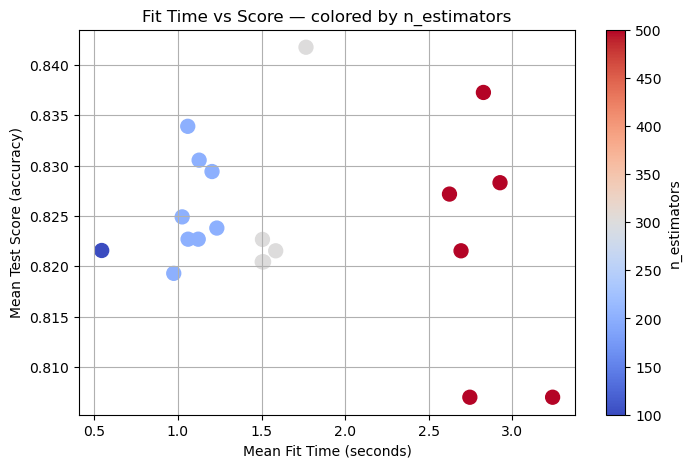

In [4]:
results = pd.DataFrame(random_search.cv_results_)

plt.figure(figsize=(8, 5))
scatter = plt.scatter(
    results['mean_fit_time'],
    results['mean_test_score'],
    c=results['param_model__n_estimators'].astype(float),
    cmap='coolwarm',
    s=100
)
plt.colorbar(scatter, label='n_estimators')
plt.xlabel('Mean Fit Time (seconds)')
plt.ylabel('Mean Test Score (accuracy)')
plt.title('Fit Time vs Score — colored by n_estimators')
plt.grid(True)
plt.savefig('cv_results_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# Save best model with joblib:

In [6]:
import joblib
import os

# create models folder
os.makedirs('models', exist_ok=True)

# best model from RandomizedSearchCV
best_pipeline = random_search.best_estimator_

# save
joblib.dump(best_pipeline, 'models/rf_best.pkl')
print("Model saved to models/rf_best.pkl")

# verify — load it back and check score
loaded_model = joblib.load('models/rf_best.pkl')
print(f"Loaded model score: {loaded_model.score(X, y):.4f}")

Model saved to models/rf_best.pkl
Loaded model score: 0.8923


# Why save with joblib instead of retraining:
Retraining Random Forest (300 trees, RandomizedSearchCV):
→ takes 5-10 minutes every time
→ wastes compute resources
→ results might slightly differ each run

Loading saved model:
→ takes 1 second
→ exact same model every time
→ ready to predict immediately

# Evaluate_model() on final pipeline:

In [7]:
import sys
sys.path.append('../')
from src.utils import evaluate_model

# evaluate best model
print("Evaluating best Random Forest pipeline:")
results = evaluate_model(best_pipeline, X, y)

Evaluating best Random Forest pipeline:
   MODEL EVALUATION
  Accuracy : 0.8418 ± 0.0298
  F1 Score : 0.7812


# ✅ GridSearchCV — 30 combinations
# ✅ RandomizedSearchCV — 20 combinations
# ✅ cv_results_ scatter — fit time vs score, colored by n_estimators
# ✅ Insight — more trees ≠ better score, check tradeoff
# ✅ Save best model with joblib
# ✅ evaluate_model() on final pipeline — 84.18%